In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
data = yf.download("RELIANCE.NS", start="2015-01-01", end="2024-01-01")

# Fix MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]

data.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,189.999817,190.877171,189.090366,189.657446,2963643
2015-01-02,189.496918,191.743797,189.229441,190.042585,7331366
2015-01-05,187.421265,190.641790,187.046782,189.379255,10103941
2015-01-06,178.915253,186.811408,178.037899,186.169449,18627980
2015-01-07,182.809814,183.772761,179.107830,179.129229,20720312


In [3]:
data = data.dropna()

In [4]:
# Moving averages
data['SMA_10'] = data['Close'].rolling(10).mean()
data['SMA_50'] = data['Close'].rolling(50).mean()

# EMA
data['EMA_10'] = data['Close'].ewm(span=10).mean()

# Returns
data['Returns'] = data['Close'].pct_change()

# Volatility
data['Volatility'] = data['Returns'].rolling(10).std()

In [5]:
from ta.momentum import RSIIndicator

data['Close'] = data['Close'].squeeze()

rsi = RSIIndicator(close=data['Close'], window=14)
data['RSI'] = rsi.rsi()

In [6]:
data = data.dropna()

In [17]:
def create_signal(x):
    if x > 0.005:
        return 2   # BUY
    elif x < -0.005:
        return 0   # SELL
    else:
        return 1   # HOLD

data['Signal'] = data['Future_Return'].apply(create_signal)

In [18]:
print(data['Signal'].value_counts())

Signal
2    812
0    728
1    631
Name: count, dtype: int64


In [19]:
features = ['Close', 'SMA_10', 'SMA_50', 'EMA_10', 'RSI', 'Volume', 'Volatility']
X = data[features]
y = data['Signal']

In [20]:
split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [23]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [24]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

C:\Users\sujan\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:05:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [25]:
def evaluate_model(y_true, y_pred, name):
    print(f"\n🔹 {name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

evaluate_model(y_test, lr_pred, "Logistic Regression")
evaluate_model(y_test, rf_pred, "Random Forest")
evaluate_model(y_test, xgb_pred, "XGBoost")


🔹 Logistic Regression
Accuracy: 0.31724137931034485
              precision    recall  f1-score   support

           0       0.31      0.37      0.33       139
           1       0.00      0.00      0.00       157
           2       0.32      0.63      0.43       139

    accuracy                           0.32       435
   macro avg       0.21      0.33      0.25       435
weighted avg       0.20      0.32      0.24       435


🔹 Random Forest
Accuracy: 0.335632183908046
              precision    recall  f1-score   support

           0       0.33      0.68      0.44       139
           1       0.29      0.04      0.07       157
           2       0.36      0.33      0.34       139

    accuracy                           0.34       435
   macro avg       0.32      0.35      0.28       435
weighted avg       0.32      0.34      0.28       435


🔹 XGBoost
Accuracy: 0.35172413793103446
              precision    recall  f1-score   support

           0       0.34      0.53      0.42 

C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


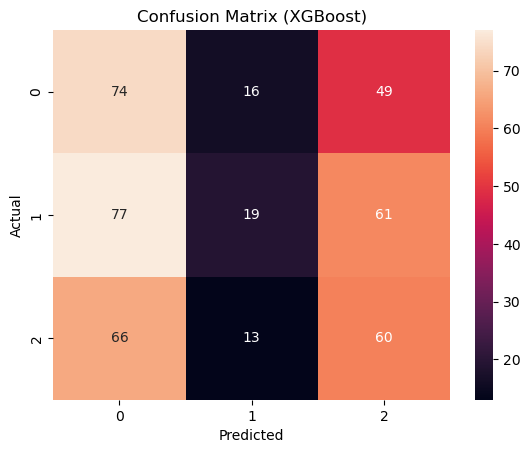

In [26]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

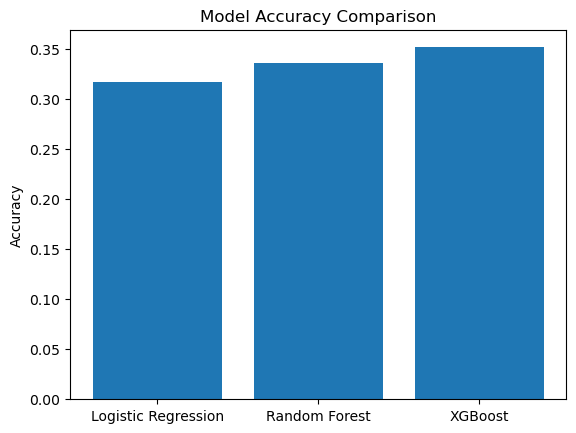

In [27]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]
accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

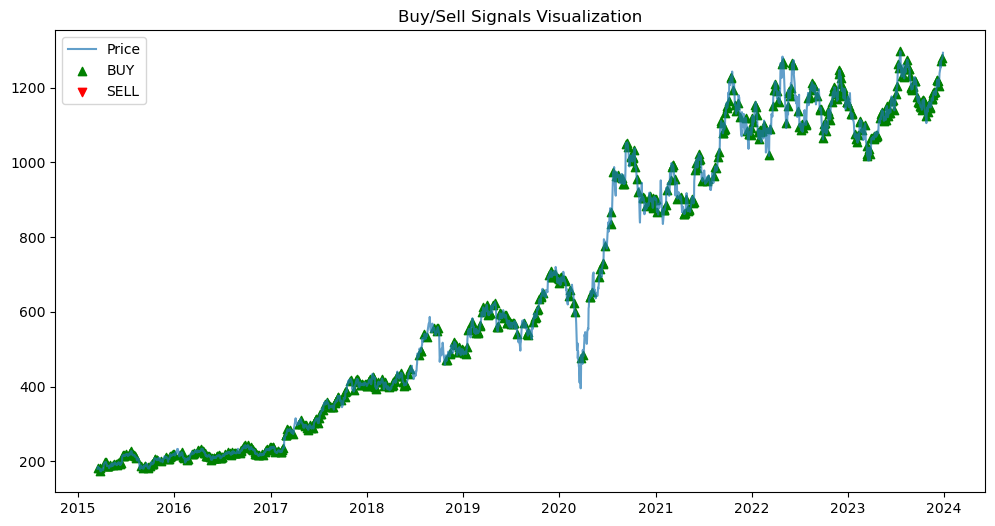

In [28]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label="Price", alpha=0.7)

buy = data[data['Signal'] == 1]
sell = data[data['Signal'] == -1]

plt.scatter(buy.index, buy['Close'], color='green', label='BUY', marker='^')
plt.scatter(sell.index, sell['Close'], color='red', label='SELL', marker='v')

plt.legend()
plt.title("Buy/Sell Signals Visualization")
plt.show()

In [29]:
import pickle

pickle.dump(xgb, open("signal_model.pkl", "wb"))
pickle.dump(scaler, open("signal_scaler.pkl", "wb"))
